# 2η Εργασία

Μπαρμπαγιάννος Βασίλειος

ΑΕΜ: 10685

Τμήμα Ηλεκτρολόγων Μηχανικών και Μηχανικών Υπολογιστών


# Εκφώνηση

Να γραφεί πρόγραμμα σε οποιαδήποτε γλώσσα προγραμματισμού το οποίο να υλοποιεί ένα
Support Vector Machine που θα εκπαιδευτεί για να επιλύει ένα από τα παρακάτω προβλήματα:
1. Διαχωρισμό 2 ή όλων των κλάσεων που υπάρχουν στις Cifar-10 ή SVHN και βρίσκονται
στις παρακάτω διευθύνσεις:

https://www.cs.toronto.edu/~kriz/cifar.html

http://ufldl.stanford.edu/housenumbers/

2. ή να επιλύει οποιοδήποτε πρόβλημα κατηγοριοποίησης πολλών κλάσεων από τις βάσεις
που βρίσκονται στις παρακάτω σελίδες:

http://archive.ics.uci.edu/ml/

http://www.cs.toronto.edu/~roweis/data.html

http://www.cs.cmu.edu/~cil/v-images.html

https://www.kaggle.com/datasets

Όπου δεν υπάρχει σύνολο ελέγχου χωρίζεται η βάση τυχαία σε σύνολο εκπαίδευσης (60%) και
ελέγχου (40%) ή ακολουθείται τεχνική cross-validation.

**Εξαγωγή Χαρακτηριστικών**

Για το διαχωρισμό των δειγμάτων μπορεί, αν χρειάζεται, να μειώνεται πρώτα η διάσταση των
δεδομένων χρησιμοποιώντας PCA ώστε να κρατήσετε περισσότερο από 90% της πληροφορίας.

**Έκθεση αποτελεσμάτων**

Θα πρέπει να γραφεί έκθεση στην οποία να περιγράφονται: ο αλγόριθμος, να δίνονται
χαρακτηριστικά παραδείγματα ορθής και εσφαλμένης κατηγοριοποίησης καθώς και ποσοστά
επιτυχίας στα στάδια της εκπαίδευσης (training) και του ελέγχου (testing), χρόνος εκπαίδευσης και
ποσοστά επιτυχίας για διαφορετικούς πυρήνες, γραμμικό και μη γραμμικούς καθώς και διαφορετικές
τιμές των παραμέτρων εκπαίδευσης. Να συγκριθεί η απόδοση του SVM σε σχέση με την
κατηγοριοποίηση 1 και 3 πλησιέστερου γείτονα (Nearest Neighbor) και πλησιέστερου κέντρου κλάσης
(Nearest Class Centroid) καθώς επίσης και με ένα MLP με ένα κρυφό επίπεδο που θα χρησιμοποιεί
Hinge loss για την βελτιστοποίηση. Να σχολιασθούν τα αποτελέσματα και ο κώδικας.

# 1 Λήψη δεδομένων και εισαγωγή απαραίτητων βιβλιοθηκών


In [1]:
# Κατεβάζουμε το dataset (αν δεν υπάρχει ήδη).
!wget -N https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz

# Αποσυμπιέζουμε το αρχείο.
!tar -xzf cifar-100-python.tar.gz

# Εισάγουμε τις απαραίτητες βιβλιοθήκες.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import time
import pickle
import os

# Βιβλιοθήκες για το SVM.
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.model_selection import GridSearchCV
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Βιβλιοθήκες για το SVM.
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Ελέγχουμε αν υπάρχει GPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


--2025-12-11 17:56:31--  https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 169001437 (161M) [application/x-gzip]
Saving to: ‘cifar-100-python.tar.gz’

cifar-100-python.ta 100%[===================>] 161.17M  59.4MB/s    in 2.7s    

2025-12-11 17:56:34 (59.4 MB/s) - ‘cifar-100-python.tar.gz’ saved [169001437/169001437]

Using device: cpu


# 2 Εξαγωγή των δεδομένων


Loaded CIFAR-100: x_train (50000, 3072) x_test (10000, 3072) classes 100


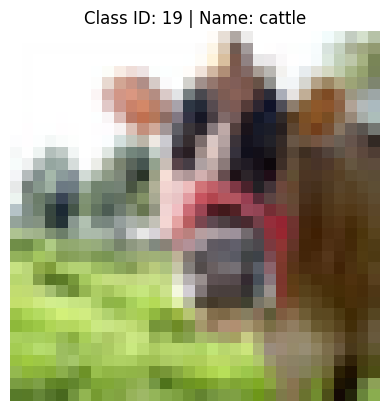

In [2]:
# Φάκελος στον οποίο βρίσκεται το CIFAR-100 dataset.
DATA_DIR = "cifar-100-python"

# Unpickle των δεδομένων.
def unpickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f, encoding='bytes')

# Φορτώνω τα train και test datasets.
train_dict = unpickle(os.path.join(DATA_DIR, "train"))
test_dict = unpickle(os.path.join(DATA_DIR, "test"))
meta_dict = unpickle(os.path.join(DATA_DIR, "meta"))

# Αποθήκευση των εικόνων και των ετικετών σε numpy arrays (για ταχύτητα).
x_train = train_dict[b'data'] # διάνυσμα 50.000x3072.
y_train = np.array(train_dict[b'fine_labels'], dtype=np.int64) # ετικέτες από 0 έως 99 (100 κλάσεις).
x_test = test_dict[b'data'] # διάνυσμα 10.000x3072.
y_test = np.array(test_dict[b'fine_labels'], dtype=np.int64)

# Λίστα με τα ονόματα των κλάσεων.
label_names = [n.decode('utf-8') for n in meta_dict[b'fine_label_names']]

print("Loaded CIFAR-100: x_train", x_train.shape, "x_test", x_test.shape, "classes", len(label_names))

# Συνάρτηση που μετατρέπει τις εικόνες από flat διανύσματα 1x3072 σε εικόνα Height, Width, Channel (32x32x3).
def flat_to_img_uint8(row):
    r = row[0:1024].reshape(32,32) # red.
    g = row[1024:2048].reshape(32,32) # green.
    b = row[2048:3072].reshape(32,32) # blue.
    img = np.dstack([r,g,b]).astype(np.uint8)
    return img

# Οπτικός έλεγχος μιας τυχαίας εικόνας για επιβεβαίωση
def plot_image(x_vector, y_label, class_names):
    # Μετατροπή από flat (3072) σε εικόνα (32, 32, 3)
    # Τα πρώτα 1024 είναι Red, τα επόμενα Green, τα τελευταία Blue
    r = x_vector[0:1024].reshape(32, 32)
    g = x_vector[1024:2048].reshape(32, 32)
    b = x_vector[2048:3072].reshape(32, 32)
    img = np.dstack([r, g, b]).astype(np.uint8)

    plt.imshow(img)
    plt.title(f"Class ID: {y_label} | Name: {class_names[y_label]}")
    plt.axis('off')
    plt.show()

# Δείξε την 1η εικόνα του train set.
plot_image(x_train[0], y_train[0], label_names)

# 3 Ανάλυση Κύριων Συνιστωσών - PCA


In [3]:
# Κρατάω όλες τις κλάσεις.
# x_train: (50000, 3072)
# y_train: (50000,) με τιμές 0-99
print(f"Αρχικές Διαστάσεις (Train): {x_train.shape}")

# Κανονικοποίηση των δεδομένων.
# Μετασχηματίζουμε τα δεδομένα ώστε να έχουν μέση τιμή 0 και τυπική απόκλιση 1.

scaler = StandardScaler()

# Υπολογίζουμε τη μετατροπή στο train set και την εφαρμόζουμε.
x_train_scaled = scaler.fit_transform(x_train.astype(float))
# Εφαρμόζουμε την ίδια μετατροπή στο test set.
x_test_scaled = scaler.transform(x_test.astype(float))

# Εφαρμογή PCA (διατήρηση του 95% της πληροφορίας).
pca = PCA(n_components=0.95) # n_components = 0.95 => ποσοστό διακύμανσης 95%.
# Δηλαδή κράτησε τόσες στήλες όσες χρειάζονται για την διατήρηση του 95% της πληροφορίας.

# Χρονομετρώ.
start_time = time.time()

# Το PCA μαθαίνει ποιες διαστάσεις είναι σημαντικές από το train set
# και αποφασίζει πόσες στήλες θα κρατήσει, αυτόματα, από μόνο του.
x_train_pca = pca.fit_transform(x_train_scaled)
# Και προσαρμόζει το test set σε αυτές τις νέες διαστάσεις.
x_test_pca = pca.transform(x_test_scaled)

pca_time = time.time() - start_time # Μέτρηση διάρκειας εφαρμογής PCA (για στατιστικούς λόγους).
print(f"\nΤο PCA ολοκληρώθηκε σε {(pca_time/60):.2f} λεπτά.")

print(f"\nΔιαστάσεις πριν το PCA: {x_train.shape}")
print(f"Διαστάσεις μετά το PCA: {x_train_pca.shape}")
print(f"\nΑριθμός συνιστωσών (νέες στήλες) που διατηρήθηκαν: {pca.n_components_}")
print(f"Συνολική διακύμανση (πληροφορία) που κρατήσαμε (για επαλήθευση): {np.sum(pca.explained_variance_ratio_) * 100:.2f}%")

# Φτιάχνουμε τις μεταβλητές που θα μπουν στα μοντέλα.
X_train_final = x_train_pca
y_train_final = y_train

X_test_final = x_test_pca
y_test_final = y_test

Αρχικές Διαστάσεις (Train): (50000, 3072)

Το PCA ολοκληρώθηκε σε 3.80 λεπτά.

Διαστάσεις πριν το PCA: (50000, 3072)
Διαστάσεις μετά το PCA: (50000, 207)

Αριθμός συνιστωσών (νέες στήλες) που διατηρήθηκαν: 207
Συνολική διακύμανση (πληροφορία) που κρατήσαμε (για επαλήθευση): 95.02%


# 4 Εύρεση βέλτιστων παραμέτρων


In [4]:
# Παίρνουμε τυχαία 2.000 δείγματα (με shuffling!) από τα 50.000 για να βρούμε
# τις παραμέτρους γρήγορα. Ουσιαστικά επιλέγω ένα υποσύνολο των 50.000 εικόνων.
# Χρησιμοποιούμε λίγα δεδομένα για να βρούμε τις βέλτιστες παραμέτρους.
# Οι 2.000 εικόνες είναι αντιπροσωπευτικό δείγμα; Ελπίζουμε ναι, αφού επιλέξαμε shuffle.
X_train_sub, y_train_sub = shuffle(X_train_final, y_train_final, random_state=42, n_samples=2000)

print(f"Εκκίνηση GridSearch σε υποσύνολο {X_train_sub.shape}...")

# Φτιάχνω έναν πίνακα (grid - πλέγμα παραμέτρων) με όλους τους συνδυασμούς (πχ C=1 και Gamma=scale),
# εκπαιδεύω ένα SVM για καθένα συνδυασμό, μετράω την ακρίβεια και κρατάω τον καλύτερο.

# Η άσκηση ζητάει γραμμικούς και μη γραμμικούς πυρήνες και διαφορετικές παραμέτρους.
param_grid = [
    # Περίπτωση: RBF Kernel, μη γραμμικό.
    # Το C ελέγχει πόσο αυστηρό είναι το μοντέλο στα λάθη.
    # Το gamma ελέγχει την εμβέλεια της επιρροής κάθε δείγματος.
    {'kernel': ['rbf'], 'C': [1, 10, 100], 'gamma': ['scale', 0.01, 0.001]},

    # Περίπτωση: Linear Kernel, γραμμικό.
    # Γρηγορότερο.
    {'kernel': ['linear'], 'C': [1, 10]}
]

# verbose=2: Για να βλέπουμε τι γίνεται όσο τρέχει.
# n_jobs=-1: Χρησιμοποίησε όλους τους επεξεργαστές του Colab.
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2, cv=3, n_jobs=-1)

start_time_grid = time.time()
grid.fit(X_train_sub, y_train_sub)
grid_time = time.time() - start_time_grid # Χρονομέτρηση για στατιστικούς λόγους.

print(f"\n--- Αποτελέσματα GridSearch (σε {grid_time:.2f} sec) ---")
print(f"Βέλτιστες Παράμετροι: {grid.best_params_}")
print(f"Καλύτερη Ακρίβεια (στο subset): {grid.best_score_:.4f}")

# Παίρνουμε τα αποτελέσματα από το GridSearch που έτρεξε πριν.
results = pd.DataFrame(grid.cv_results_)

# param_kernel: Ο πυρήνας (linear vs rbf).
# param_C: Η παράμετρος C.
# param_gamma: Η παράμετρος gamma.
# mean_test_score: Η ακρίβεια που πέτυχε.
table = results[['param_kernel', 'param_C', 'param_gamma', 'mean_test_score']]

table.columns = ['Kernel', 'C', 'Gamma', 'Accuracy']
table = table.sort_values(by='Accuracy', ascending=False)

print("\n--- Πίνακας Αποτελεσμάτων ---")
print(table)

Εκκίνηση GridSearch σε υποσύνολο (2000, 207)...
Fitting 3 folds for each of 11 candidates, totalling 33 fits

--- Αποτελέσματα GridSearch (σε 38.94 sec) ---
Βέλτιστες Παράμετροι: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Καλύτερη Ακρίβεια (στο subset): 0.1250

--- Πίνακας Αποτελεσμάτων ---
    Kernel    C  Gamma  Accuracy
3      rbf   10  scale  0.125001
6      rbf  100  scale  0.125001
5      rbf   10  0.001  0.114503
8      rbf  100  0.001  0.114503
0      rbf    1  scale  0.110008
10  linear   10    NaN  0.106506
9   linear    1    NaN  0.106506
2      rbf    1  0.001  0.095505
1      rbf    1   0.01  0.016000
4      rbf   10   0.01  0.016000
7      rbf  100   0.01  0.016000


# 5 Τελική εκπαίδευση και αξιολόγηση


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Εκπαιδεύω και αξιολογώ το τελικό μοντέλο.
# Χρησιμοποιούμε τις παραμέτρους που βρήκε το GridSearch (grid.best_estimator_).
best_svm = grid.best_estimator_

# Για την τελική εκπαίδευση, χρησιμοποιούμε περισσότερα δεδομένα.
# Για ταχύτερη εκπαίδευση, επιλέγω 10.000 εικόνες (παραδείγματος χάρη).
# Για καλύτερη ακρίβεια, βάζω και τις 50.000 εικόνες.
TRAIN_SIZE = 50000 # Πόσες εικόνες βάζω.
X_train_final_subset, y_train_final_subset = shuffle(X_train_final, y_train_final, random_state=42, n_samples=TRAIN_SIZE)

print(f"\nΕκπαίδευση του βέλτιστου SVM σε {TRAIN_SIZE} δείγματα.")

start_time_train = time.time() # Έναρξη χρονομέτρησης για το train.
# Εκπαίδευση στο train set. Το μοντέλο εκπαιδεύεται στις 50.000 εικόνες.
best_svm.fit(X_train_final_subset, y_train_final_subset)
train_time = time.time() - start_time_train # Λήξη χρονομέτρησης για το train.

start_time_test = time.time() # Έναρξη χρονομέτρησης για το test.
# Πρόβλεψη στο test set. Το CIFAR-100 έχει 10.000 εικόνες για test.
y_test_pred = best_svm.predict(X_test_final)
test_time = time.time() - start_time_test # Λήξη χρονομέτρησης για το test.

# Πρόβλεψη στο train set.
y_train_pred = best_svm.predict(X_train_final_subset[:10000])

# Ακρίβεια στο train set.
train_acc = accuracy_score(y_train_final_subset[:10000], y_train_pred)

# Υπολογισμός συνολικής ακρίβειας (δηλαδή ακρίβειας στο test set).
# final_acc = test_acc.
final_acc = accuracy_score(y_test_final, y_test_pred)

print("-" * 40)
print(f"Training Accuracy: {train_acc:.4%} (Εκπαίδευση)")
print(f"Τελική Ακρίβεια (Accuracy): {final_acc:.4%} (Έλεγχος)")
print(f"Χρόνος Εκπαίδευσης (Train Time): {train_time/60:.2f} λεπτά")
print(f"Χρόνος Πρόβλεψης (Test Time):    {test_time/60:.2f} λεπτά")
print("-" * 40)



Εκπαίδευση του βέλτιστου SVM σε 50000 δείγματα.


KeyboardInterrupt: 

In [5]:
"""
Ποσοστά επιτυχίας για διαφορετικούς πυρήνες (linear vs rbf), διαφορετικές
τιμές παραμέτρων (C=1 vs C=10) και διαφορετικά gamma (scale και auto).
"""

import time
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.utils import shuffle

# 1. Πλήρες dataset για τα RBF Kernels (50.000 εικόνες).
TRAIN_SIZE_FULL = 50000
X_train_full, y_train_full = shuffle(X_train_final, y_train_final, random_state=42, n_samples=TRAIN_SIZE_FULL)

# 2. Μειωμένο dataset για το Linear Kernel (10.000 εικόνες, για να μην περιμένουμε ώρες).
TRAIN_SIZE_LIN = 10000
X_train_lin, y_train_lin = shuffle(X_train_final, y_train_final, random_state=42, n_samples=TRAIN_SIZE_LIN)

print(f"RBF θα τρέξει σε: {TRAIN_SIZE_FULL} δείγματα.")
print(f"Linear θα τρέξει σε: {TRAIN_SIZE_LIN} δείγματα.\n")

# Τα πειράματά μου.
experiment_configs = [
    # 1. RBF, C=10.
    {'kernel': 'rbf',    'C': 10, 'gamma': 'scale'},

    # 2. RBF, C=1.
    {'kernel': 'rbf',    'C': 1,  'gamma': 'scale'},

    # 3. Linear, C=10.
    {'kernel': 'linear', 'C': 10, 'gamma': 'auto'}
]

# Αποθήκευση στο ιστορικό.
results_log = []

for config in experiment_configs:
    kernel_type = config['kernel']
    C_val = config['C']
    gamma_val = config['gamma']

    # Επιλογή dataset ανάλογα με τον πυρήνα.
    if kernel_type == 'linear':
        # Αν είναι linear, πάρε το μικρό σετ (με τις 10.000 εικόνες).
        current_X_train = X_train_lin
        current_y_train = y_train_lin
        current_samples = TRAIN_SIZE_LIN
        note = f"({TRAIN_SIZE_LIN} εικόνες)"
    else:
        # Αν είναι rbf, πάρε ολόκληρο το set.
        current_X_train = X_train_full
        current_y_train = y_train_full
        current_samples = TRAIN_SIZE_FULL
        note = f"({TRAIN_SIZE_FULL} εικόνες))"

    exp_name = f"C={C_val}, gamma={gamma_val}, kernel={kernel_type}"

    print("-" * 80)
    print(f"Running: {exp_name} {note}")

    # 1. Δημιουργία Μοντέλου.
    clf = SVC(kernel=kernel_type, C=C_val, gamma=gamma_val, cache_size=1000)

    # 2. Εκπαίδευση στο train set.
    start_train = time.time()
    clf.fit(current_X_train, current_y_train)
    train_time = (time.time() - start_train) / 60 # σε λεπτά.

    # 3. Αξιολόγηση στο test set (τελική ακρίβεια).
    start_test = time.time()
    y_test_pred = clf.predict(X_test_final)
    test_time = (time.time() - start_test) / 60 # σε λεπτά
    final_acc = accuracy_score(y_test_final, y_test_pred)

    # 4. Αξιολόγηση στο train set (για έλεγχο overfitting).
    # Προσοχή: Παίρνουμε δείγμα 10.000 από το αντίστοιχο train set που χρησιμοποιήθηκε.
    y_train_pred = clf.predict(current_X_train[:10000])
    train_acc = accuracy_score(current_y_train[:10000], y_train_pred)

    # 5. Αποτελέσματα.
    print(f"Accuracy: {final_acc:.2%} (Train: {train_acc:.2%}) | Train Time: {train_time:.2f} min | Test Time: {test_time:.2f} min")

    # 6. Αποθήκευση.
    results_log.append({
        'Parameters': exp_name,
        'Kernel': kernel_type,
        'C': C_val,
        'Samples Used': current_samples,
        'Train Acc': train_acc,
        'Test Acc': final_acc,
        'Train Time (min)': round(train_time, 2),
        'Test Time (min)': round(test_time, 2)
    })

"""
# Τελικά αποτελέσματα.
df_experiments = pd.DataFrame(results_log)
pd.options.display.float_format = '{:.4f}'.format

print("\n" + "="*100)
print("ΣΥΓΚΕΝΤΡΩΤΙΚΟΣ ΠΙΝΑΚΑΣ")
print("="*100)
print(df_experiments)
print("="*100)

RBF θα τρέξει σε: 50000 δείγματα.
Linear θα τρέξει σε: 10000 δείγματα.

--------------------------------------------------------------------------------
Running: C=10, gamma=scale, kernel=rbf (Full Data)
  -> Εκπαίδευση σε 50000 δείγματα...
     Ολοκληρώθηκε σε 9.24 λεπτά.
  -> Πρόβλεψη Test Set...
  -> Πρόβλεψη Train Set (σε δείγμα)...
Accuracy: 29.40% (Train: 96.40%) | Train Time: 9.24 min | Test Time: 4.50 min
--------------------------------------------------------------------------------
Running: C=1, gamma=scale, kernel=rbf (Full Data)
  -> Εκπαίδευση σε 50000 δείγματα...
     Ολοκληρώθηκε σε 6.79 λεπτά.
  -> Πρόβλεψη Test Set...
  -> Πρόβλεψη Train Set (σε δείγμα)...
Accuracy: 26.55% (Train: 46.54%) | Train Time: 6.79 min | Test Time: 4.47 min
--------------------------------------------------------------------------------
Running: C=10, gamma=auto, kernel=linear (Reduced Data)
  -> Εκπαίδευση σε 10000 δείγματα...
     Ολοκληρώθηκε σε 0.56 λεπτά.
  -> Πρόβλεψη Test Set...
  -> Π

# 6 Παραδείγματα ορθής και εσφαλμένης ταξινόμησης


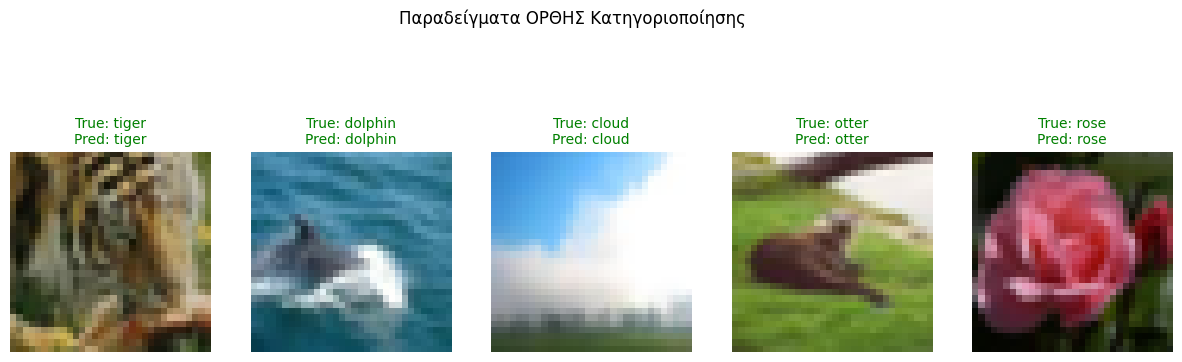

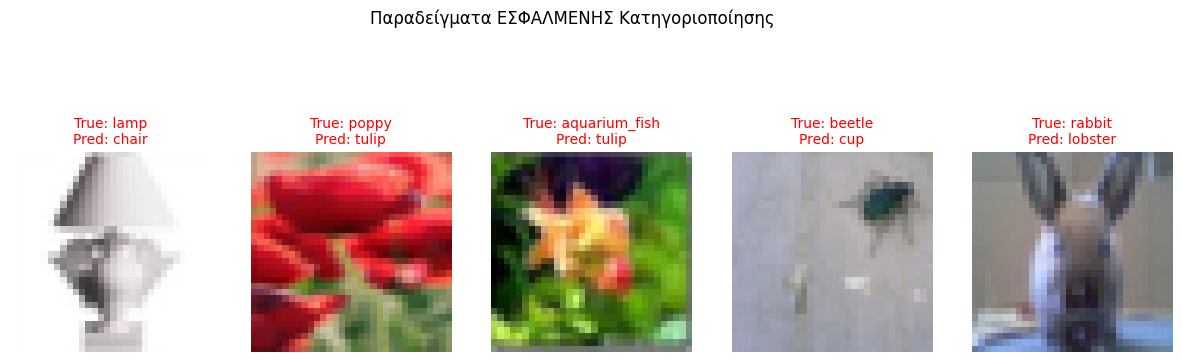

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Συνάρτηση για εμφάνιση εικόνων.
def plot_classification_examples(x_original, y_true, y_pred, label_names, correct=True, num_images=5):
    # Βρίσκουμε τα indices (θέσεις) που πληρούν τη συνθήκη (σωστό ή λάθος).
    if correct:
        indices = np.where(y_true == y_pred)[0]
        title_text = "Παραδείγματα ΟΡΘΗΣ Κατηγοριοποίησης"
    else:
        indices = np.where(y_true != y_pred)[0]
        title_text = "Παραδείγματα ΕΣΦΑΛΜΕΝΗΣ Κατηγοριοποίησης"

    # Επιλογή τυχαίων εικόνων από αυτές που βρήκαμε.
    if len(indices) > 0:
        # Αν βρήκαμε λιγότερες από 5 εικόνες, δείχνουμε όσες βρήκαμε.
        n_to_show = min(len(indices), num_images)
        selected_indices = np.random.choice(indices, n_to_show, replace=False)

        plt.figure(figsize=(15, 5))
        for i, idx in enumerate(selected_indices):
            plt.subplot(1, num_images, i + 1)

            img_flat = x_test[idx] # Παίρνουμε την flat εικόνα.

            r = img_flat[0:1024].reshape(32, 32)
            g = img_flat[1024:2048].reshape(32, 32)
            b = img_flat[2048:3072].reshape(32, 32)
            img = np.dstack([r, g, b]).astype(np.uint8)

            plt.imshow(img)

            true_label = label_names[int(y_true[idx])]
            pred_label = label_names[int(y_pred[idx])]

            if correct:
                plt.title(f"True: {true_label}\nPred: {pred_label}", color='green', fontsize=10)
            else:
                plt.title(f"True: {true_label}\nPred: {pred_label}", color='red', fontsize=10)
            plt.axis('off')

        plt.suptitle(title_text)
        plt.show()
    else:
        print(f"Δεν βρέθηκαν παραδείγματα για: {title_text}")

# 1. Εμφάνιση 5 σωστά ταξινομημένων εικόνων.
plot_classification_examples(x_test, y_test_final, y_test_pred, label_names, correct=True, num_images=5)

# 2. Εμφάνιση 5 λανθασμένα ταξινομημένων εικόνων.
plot_classification_examples(x_test, y_test_final, y_test_pred, label_names, correct=False, num_images=5)

# 7 Multilayer Perceptron με Hingle Loss


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import time
from sklearn.metrics import accuracy_score

# Ελέγχουμε αν υπάρχει διαθέσιμη GPU για επιτάχυνση. Αλλιώς χρησιμοποιούμε την CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [9]:
# Μετατροπή σε PyTorch Tensors.
# .float() για τα δεδομένα εισόδου,
# .long() για τις ετικέτες των κλάσεων.
x_train_torch = torch.tensor(X_train_final, dtype=torch.float32).to(device)
y_train_torch = torch.tensor(y_train_final, dtype=torch.long).to(device)

x_test_torch = torch.tensor(X_test_final, dtype=torch.float32).to(device)
y_test_torch = torch.tensor(y_test_final, dtype=torch.long).to(device)

# Δημιουργία DataLoader, ώστε να παίρνουμε τα δεδομένα σε μικρά πακέτα (batches) κατά την εκπαίδευση.
BATCH_SIZE = 64

train_dataset = TensorDataset(x_train_torch, y_train_torch)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)



In [19]:
class MLP_Hinge(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP_Hinge, self).__init__()

        # Πρώτο επίπεδο: από την είσοδο στο hidden layer.
        self.fc1 = nn.Linear(input_dim, hidden_dim)

        # Συνάρτηση ενεργοποίησης ReLU (εισάγει τη μη γραμμικότητα).
        self.relu = nn.ReLU()

        # Δεύτερο επίπεδο: Από το κρυφό επίπεδο στην έξοδο.
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    # Το forward pass.
    def forward(self, x):
        # Πέρασμα από το πρώτο επίπεδο.
        out = self.fc1(x)
        # Εφαρμογή ReLU.
        out = self.relu(out)
        # Πέρασμα από το δεύτερο επίπεδο (έξοδος).
        out = self.fc2(out)
        return out

# Ορίζουμε τις διαστάσεις κάθε επιπέδου.
INPUT_DIM = X_train_final.shape[1] # Αυτόματη ανίχνευση από το PCA shape.
HIDDEN_DIM = 128 # Tο μέγεθος του κρυφού επιπέδου. Μπορώ να βάλω 128, 256, 512.
# 256 είναι τα νέα χαρακτηριστικά που παράγει το κρυφό επίπεδο αφότου λάβει τα 209 της εισόδου.
OUTPUT_DIM = 100 # CIFAR-100 classes.

# Δημιουργία του μοντέλου.
model = MLP_Hinge(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM).to(device)
print(model)


MLP_Hinge(
  (fc1): Linear(in_features=207, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=100, bias=True)
)


In [22]:
# Ορισμός Hinge Loss (Multi-class version).
criterion = nn.MultiMarginLoss(p=1, margin=1.0)

# Ορισμός Optimizer (Adam).
learning_rate = 0.01
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [17]:
# Εκπαίδευση του μοντέλου στο train set και εκτύπωση loss κάθε 5 εποχές.

EPOCHS = 100 # Αριθμός εποχών εκπαίδευσης.

print(f"Εκκίνηση εκπαίδευσης MLP για {EPOCHS} εποχές.")
start_time_mlp = time.time()

loss_history = []

# Βάζουμε το μοντέλο σε mode εκπαίδευσης.
model.train()

# Training loop.
for epoch in range(EPOCHS):
    running_loss = 0.0
    for inputs, labels in train_loader:
        # 1. Μηδενισμός των gradients από το προηγούμενο βήμα.
        optimizer.zero_grad()

        # 2. Forward pass: Υπολογισμός προβλέψεων.
        outputs = model(inputs)

        # 3. Υπολογισμός σφάλματος (Hinge Loss).
        loss = criterion(outputs, labels)

        # 4. Backward pass: Υπολογισμός gradients (backpropagation).
        loss.backward()

        # 5. Ενημέρωση βαρών.
        optimizer.step()

        running_loss += loss.item()

    # Μέσος όρος loss για την εποχή.
    epoch_loss = running_loss / len(train_loader)
    loss_history.append(epoch_loss)

    # Εκτύπωση κάθε 5 εποχές.
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {epoch_loss:.4f}")

train_time_mlp = time.time() - start_time_mlp
print(f"Χρόνος Εκπαίδευσης MLP: {train_time_mlp/60:.2f} λεπτά")

Εκκίνηση εκπαίδευσης MLP για 100 εποχές.
Epoch [5/100], Loss: 0.8206
Epoch [10/100], Loss: 0.7000
Epoch [15/100], Loss: 0.5697
Epoch [20/100], Loss: 0.5055
Epoch [25/100], Loss: 0.4663
Epoch [30/100], Loss: 0.4669
Epoch [35/100], Loss: 0.4374
Epoch [40/100], Loss: 0.4094
Epoch [45/100], Loss: 0.3913
Epoch [50/100], Loss: 0.3910
Epoch [55/100], Loss: 0.3989
Epoch [60/100], Loss: 0.3785
Epoch [65/100], Loss: 0.4083
Epoch [70/100], Loss: 0.3615
Epoch [75/100], Loss: 0.3475
Epoch [80/100], Loss: 0.3494
Epoch [85/100], Loss: 0.3551
Epoch [90/100], Loss: 0.3907
Epoch [95/100], Loss: 0.3310
Epoch [100/100], Loss: 0.3511
Χρόνος Εκπαίδευσης MLP: 5.05 λεπτά


Υπολογισμός ακρίβειας στο test set.


In [14]:
# Βάζουμε το μοντέλο σε mode αξιολόγησης
model.eval()

print("Υπολογισμός Ακρίβειας στο Test Set...")
start_test_mlp = time.time()

with torch.no_grad(): # Δεν χρειαζόμαστε gradients εδώ
    # Πρόβλεψη στο Test set
    outputs_test = model(x_test_torch)

    # Η πρόβλεψη είναι η κλάση με το μέγιστο σκορ
    _, predicted_test = torch.max(outputs_test.data, 1)

    # Μετατροπή σε numpy για το accuracy_score
    predicted_test_np = predicted_test.cpu().numpy()
    y_test_np = y_test_torch.cpu().numpy()

    # Πρόβλεψη στο Train set (για έλεγχο overfitting)
    outputs_train = model(x_train_torch)
    _, predicted_train = torch.max(outputs_train.data, 1)
    predicted_train_np = predicted_train.cpu().numpy()
    y_train_np = y_train_torch.cpu().numpy()

test_time_mlp = time.time() - start_test_mlp

# Υπολογισμός Ακρίβειας
acc_mlp_test = accuracy_score(y_test_np, predicted_test_np)
acc_mlp_train = accuracy_score(y_train_np, predicted_train_np)

print("-" * 50)
print(f"MLP Training Accuracy:       {acc_mlp_train:.4%}")
print(f"MLP Testing Accuracy:        {acc_mlp_test:.4%} (best)")
print("-" * 50)
print(f"Χρόνος Εκπαίδευσης:          {train_time_mlp/60:.2f} λεπτά")
print(f"Χρόνος Πρόβλεψης (Test):     {test_time_mlp:.2f} δευτερόλεπτα")
print("-" * 50)

Υπολογισμός Ακρίβειας στο Test Set...
--------------------------------------------------
MLP Training Accuracy:       56.4940%
MLP Testing Accuracy:        19.3300%
--------------------------------------------------
Χρόνος Εκπαίδευσης:          5.73 λεπτά
Χρόνος Πρόβλεψης (Test):     0.29 δευτερόλεπτα
--------------------------------------------------


In [23]:
import time
from sklearn.metrics import accuracy_score
import torch

# Υπολογισμός ακρίβειας κάθε 5 εποχές και αποθήκευση της καλύτερης ακρίβειας της εποχής.

# Εποχές.
EPOCHS = 100

# Αρχικοποίηση μεταβλητών για το "Early Stopping".
best_test_acc = 0.0
best_epoch = 0

print(f"Εκκίνηση εκπαίδευσης MLP για {EPOCHS} εποχές, {HIDDEN_DIM} νευρώνες και {learning_rate} learning rate.")

loss_history = []
cumulative_train_time = 0.0 # Καθαρός χρόνος εκπαίδευσης (για όλη την εκπαίδευση, όχι για κάθε εποχή).

# Μετατροπή των labels σε numpy μια φορά για να μην το κάνουμε συνέχεια μέσα στο loop.
y_train_np_static = y_train_torch.cpu().numpy()
y_test_np_static = y_test_torch.cpu().numpy()

# Κρατάμε και τον συνολικό χρόνο έναρξης (για το τελικό print).
total_start_time = time.time()

for epoch in range(EPOCHS):
    # 1. Εκπαίδευση.

    # Ξεκινάμε το χρονόμετρο της εποχής.
    epoch_start_time = time.time()

    model.train() # Βάζουμε το μοντέλο σε mode εκπαίδευσης.
    running_loss = 0.0

    for inputs, labels in train_loader:
        optimizer.zero_grad() # Μηδενισμός gradients.
        outputs = model(inputs) # forward pass.
        loss = criterion(outputs, labels) # υπολογισμός Loss.
        loss.backward() # backward pass.
        optimizer.step() # ενημέρωση βαρών.

        running_loss += loss.item()

    # Σταματάμε το χρονόμετρο της εποχής και προσθέτουμε το χρόνο στο σύνολο.
    epoch_end_time = time.time()
    cumulative_train_time += (epoch_end_time - epoch_start_time)

    # Υπολογισμός μέσου loss εποχής.
    epoch_loss = running_loss / len(train_loader)
    loss_history.append(epoch_loss)

    # 2. Αξιολόγηση κάθε 5 εποχές.
    if (epoch + 1) % 5 == 0:
        model.eval() # Βάζουμε το μοντέλο σε mode αξιολόγησης.

        with torch.no_grad(): # Απενεργοποιούμε τα gradients για ταχύτητα.
            # Ακρίβεια στο train set (για overfitting/underfitting).
            out_train = model(x_train_torch)
            _, pred_train = torch.max(out_train, 1)
            acc_train = accuracy_score(y_train_np_static, pred_train.cpu().numpy())

            # Χρόνος που χρειάστηκε για την πρόβλεψη.
            t_infer_start = time.time() # Έναρξη μέτρησης πρόβλεψης.

            out_test = model(x_test_torch)
            _, pred_test = torch.max(out_test, 1)

            t_infer_end = time.time() # Λήξη μέτρησης πρόβλεψης.
            test_inference_time = t_infer_end - t_infer_start

            # Υπολογισμός accuracy.
            acc_test = accuracy_score(y_test_np_static, pred_test.cpu().numpy())

            # Κρατάω το best accuracy.
            if acc_test > best_test_acc:
                best_test_acc = acc_test
                best_epoch = epoch + 1
                new_record_flag = "(*)" # Σημαδάκι για να βλέπουμε το ρεκόρ.
            else:
                new_record_flag = ""

        # Εκτύπωση αποτελεσμάτων με χρόνους.
        print(f"Epoch [{epoch+1:3d}/{EPOCHS}] | Loss: {epoch_loss:.4f} | Train Acc: {acc_train:.2%} | Test Acc: {acc_test:.2%} {new_record_flag} | Train Time: {cumulative_train_time/60:.2f}m | Test Time: {test_inference_time:.3f}s")

        # Ξαναβάζουμε το μοντέλο σε mode εκπαίδευσης για την επόμενη εποχή.
        model.train()

# Τελικός συνολικός χρόνος.
total_elapsed_time = time.time() - total_start_time
print("-" * 120)
print(f"Η διαδικασία ολοκληρώθηκε σε {total_elapsed_time/60:.2f} λεπτά.")
print(f"Καλύτερο accuracy: {best_test_acc:.2%} στο epoch {best_epoch}")
print("-" * 120)

Εκκίνηση εκπαίδευσης MLP για 100 εποχές, 128 νευρώνες και 0.01 learning rate.
Epoch [  5/100] | Loss: 0.5341 | Train Acc: 17.52% | Test Acc: 13.90% (*) | Train Time: 0.21m | Test Time: 0.054s
Epoch [ 10/100] | Loss: 0.5008 | Train Acc: 16.20% | Test Acc: 12.78%  | Train Time: 0.43m | Test Time: 0.029s
Epoch [ 15/100] | Loss: 0.4732 | Train Acc: 15.88% | Test Acc: 13.27%  | Train Time: 0.65m | Test Time: 0.039s
Epoch [ 20/100] | Loss: 0.4609 | Train Acc: 15.28% | Test Acc: 11.92%  | Train Time: 0.89m | Test Time: 0.034s
Epoch [ 25/100] | Loss: 0.4604 | Train Acc: 15.67% | Test Acc: 11.94%  | Train Time: 1.09m | Test Time: 0.032s
Epoch [ 30/100] | Loss: 0.4571 | Train Acc: 15.24% | Test Acc: 11.43%  | Train Time: 1.29m | Test Time: 0.031s
Epoch [ 35/100] | Loss: 0.4466 | Train Acc: 14.89% | Test Acc: 11.65%  | Train Time: 1.50m | Test Time: 0.029s
Epoch [ 40/100] | Loss: 0.4442 | Train Acc: 15.39% | Test Acc: 11.93%  | Train Time: 1.72m | Test Time: 0.035s
Epoch [ 45/100] | Loss: 0.4411 